# Medical image captioning with ROCOv2 dataset
Using CNN + LSTM with Attention

By Naomi Josebashvili


## Setting up



In [15]:
import os

!pip install datasets rouge-score pycocoevalcap bert-score --quiet

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

import json
from datasets import load_dataset, disable_progress_bar

import pickle
from collections import Counter
from PIL import Image
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider
from bert_score import score as bert_score_fn

import matplotlib.pyplot as plt

# Directs HuggingFace cache to the drive so it doesn't fill the disk
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/NaomiDissertation/hf_cache'
os.environ['TRANSFORMERS_CACHE'] = '/content/drive/MyDrive/NaomiDissertation/hf_cache'

# Improves memory allocation
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Mounts Google Drive so that data is kept once the session ends (may need to authorise access)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_PATH = '/content/drive/MyDrive/NaomiDissertation/rocov2'
os.makedirs(DATA_PATH, exist_ok=True)

CHECKPOINT_PATH = '/content/drive/MyDrive/NaomiDissertation/rocov2/checkpoint'
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constants and hyperparameters
SUBSET_SIZES = {'train': 15000,
                'validation': 1500,
                'test': 1500}

FREQ_THRESHOLD = 1
BATCH_SIZE = 32
NUM_WORKERS = 2
ENCODED_IMAGE_SIZE = 14
ENCODER_DIM = 2048
DECODER_DIM = 512
ATTENTION_DIM = 256
EMBED_DIM = 256
DROPOUT = 0.5
NUM_EPOCHS = 20
ENCODER_UNFREEZE = 5
GRAD_CLIP = 5.
LEARNING_RATE = 4e-4
PATIENCE_LIMIT = 5
BEAM_SIZE = 3
MAX_CAPTION_LEN = 30

Mounted at /content/drive


## Download and save dataset



In [16]:
captions = {}

for split in ['train', 'validation', 'test']:

    captions_path = os.path.join(DATA_PATH, split, 'captions.json')

    if os.path.exists(captions_path):
        print(f'{split} already on Drive. Loading.')
        with open(captions_path, 'r') as f:
            captions[split] = json.load(f)

    else:
        print(f'{split} not found on Drive. Downloading.')
        split_path = os.path.join(DATA_PATH, split, 'images')
        os.makedirs(split_path, exist_ok=True)

        disable_progress_bar()
        rocov2 = load_dataset('eltorio/ROCOv2-radiology', download_mode='reuse_cache_if_exists')
        data = rocov2[split].select(range(SUBSET_SIZES[split]))

        captions[split] = {}

        for i, item in enumerate(data):
            # Saves image file name in order by padding with '0's
            image_path = os.path.join(split_path, f'{item["image_id"]}.jpg')
            item['image'].convert('RGB').save(image_path)
            captions[split][f'{item["image_id"]}.jpg'] = item['caption']

        with open(captions_path, 'w') as f:
            json.dump(captions[split], f)

train_captions = captions['train']
validation_captions = captions['validation']
test_captions = captions['test']

print(f'Train: {len(train_captions)} items')
print(f'Validation: {len(validation_captions)} items')
print(f'Test: {len(test_captions)} items')

train already on Drive. Loading.
validation already on Drive. Loading.
test already on Drive. Loading.
Train: 15000 items
Validation: 1500 items
Test: 1500 items


## Inspect some of the data

Caption: Head CT demonstrating left parotiditis.
Image size (width x height): (682, 748)


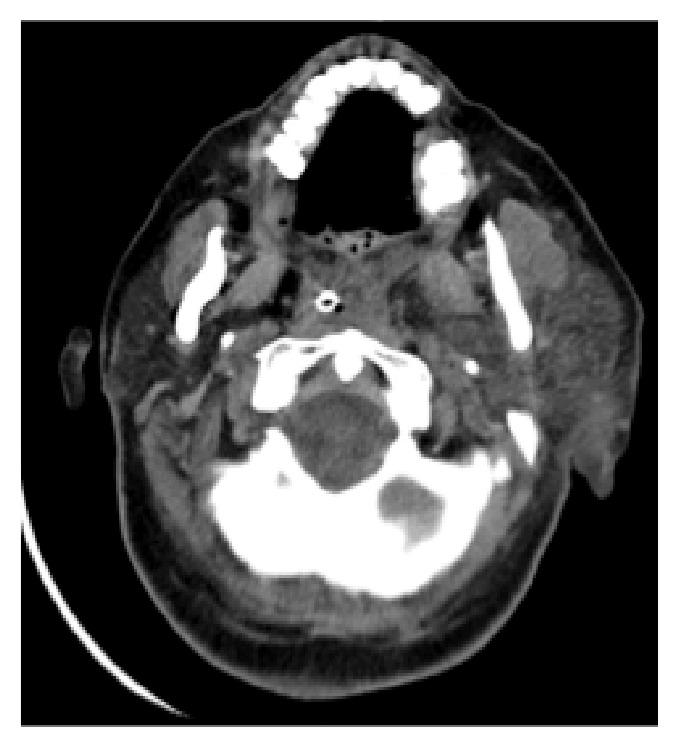




Caption: Acquired renal cysts in end-stage renal failure: 16-year-old girl with Alport syndrome and peritoneal dialysis from the age of 2 years
Image size (width x height): (307, 224)


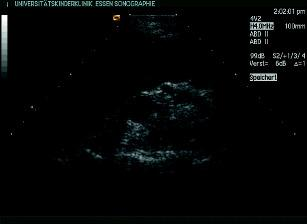




Caption: Computed tomography of the chest showing the right breast nodule with irregular margins
Image size (width x height): (358, 263)


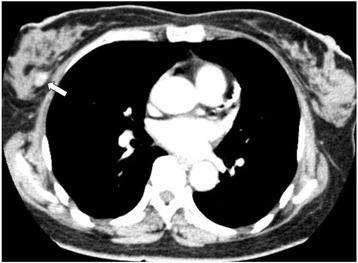




Caption: Lateral view of the sacrum showing the low contrast between bone and soft tissue.
Image size (width x height): (567, 567)


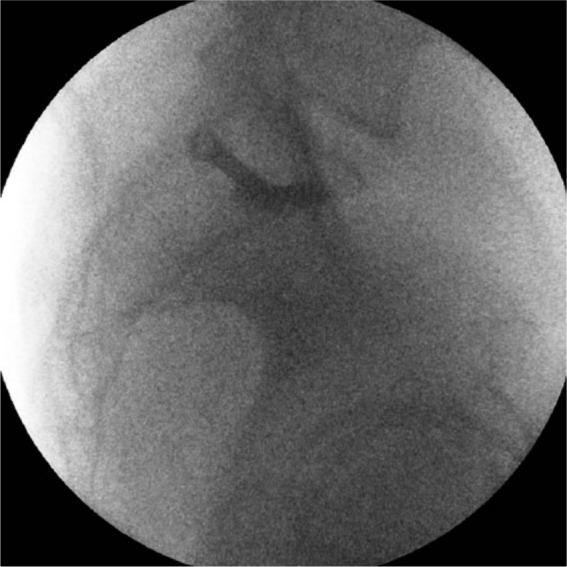




Caption: Thoracic CT scan showing perihilar pulmonary lymphadenomegaly
Image size (width x height): (600, 512)


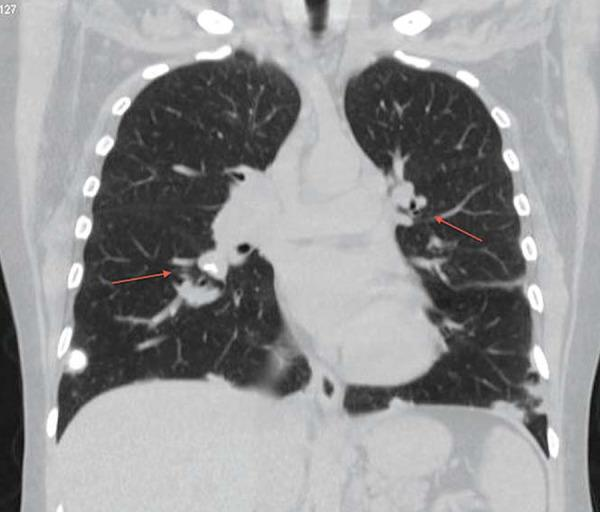

In [17]:
with open(os.path.join(DATA_PATH, 'train', 'captions.json')) as f:
    train_captions_preview = json.load(f)

items = list(train_captions_preview.items())[:5]

for filename, caption in items:
    image = Image.open(os.path.join(DATA_PATH, 'train', 'images', filename))
    print(f'Caption: {caption}')
    print(f'Image size (width x height): {image.size}')
    display(image)
    print('\n\n')

## Vocabulary

In [18]:
# Special tokens
stoi = {'<PAD>': 0,
        '<START>': 1,
        '<END>': 2,
        '<UNK>': 3}
itos = {value: key for key, value in stoi.items()}

def tokenise(text):
    return nltk.tokenize.word_tokenize(text.lower())

def build_vocab(captions):
    counter = Counter()
    for caption in captions.values():
        counter.update(tokenise(caption))

    index = len(stoi)
    for word, count in counter.items():
        if count >= FREQ_THRESHOLD:
            stoi[word] = index
            itos[index] = word
            index += 1

    print(f'Vocabulary built with {len(stoi)} words')

def caption_to_num_list(caption):
    num_list = []
    for w in tokenise(caption):
        num_list.append(stoi.get(w, stoi['<UNK>']))
    return num_list

def num_list_to_caption(indices):
    caption = []
    for index in indices:
        word = itos.get(index, '<UNK>')
        if word == '<PAD>' or word == '<START>':
            continue
        if word == '<END>':
            break
        caption.append(word)
    return ' '.join(caption)

VOCAB_PATH = os.path.join(DATA_PATH, 'vocab.pkl')

if os.path.exists(VOCAB_PATH):
    print('Vocabulary already on Drive. Loading.')
    with open(VOCAB_PATH, 'rb') as f:
        stoi, itos = pickle.load(f)
    vocab_size = len(stoi)
    print(f'Vocabulary: {vocab_size} words')
else:
    print('Building vocabulary')
    build_vocab(train_captions)
    with open(VOCAB_PATH, 'wb') as f:
        pickle.dump((stoi, itos), f)
    vocab_size = len(stoi)
    print(f'Vocab saved to Drive. Size: {vocab_size} words')

Vocabulary already on Drive. Loading.
Vocabulary: 16965 words


## Image transforms, Dataset and DataLoader

Images resized to 224x224 for ResNet-50, normalised using ImageNet mean and standard deviation

In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class ROCOv2Dataset(Dataset):
    def __init__(self, split, transform):
        self.transform = transform
        self.image_path = os.path.join(DATA_PATH, split, 'images')
        with open(os.path.join(DATA_PATH, split, 'captions.json')) as f:
            self.items = list(json.load(f).items())

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        filename, caption = self.items[index]
        image = Image.open(os.path.join(self.image_path, filename))
        image = self.transform(image)
        caption_ids = ([stoi['<START>']]
                       + caption_to_num_list(caption)
                       + [stoi['<END>']])
        return image, torch.tensor(caption_ids, dtype=torch.long)

def add_padding(batch):
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i in range(len(captions)):
        padded[i, :lengths[i]] = captions[i]
    return images, padded, torch.tensor(lengths)

train_dataset = ROCOv2Dataset('train', train_transform)
validation_dataset = ROCOv2Dataset('validation', eval_transform)
test_dataset = ROCOv2Dataset('test', eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=add_padding)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=add_padding)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=add_padding)

print(f' Train: {len(train_dataset)} images, {len(train_loader)} batches per epoch')
print(f' Validation: {len(validation_dataset)} images, {len(validation_loader)} batches per epoch')
print(f' Test: {len(test_dataset)} images, {len(test_loader)} batches per epoch')

 Train: 15000 images, 469 batches per epoch
 Validation: 1500 images, 47 batches per epoch
 Test: 1500 images, 47 batches per epoch


## Model

CNN encoder, Bahdanau atention, LSTM decoder

In [20]:
class Encoder(nn.Module):

    def __init__(self):
        super(Encoder, self).__init__()
        self.enc_image_size = ENCODED_IMAGE_SIZE

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((ENCODED_IMAGE_SIZE, ENCODED_IMAGE_SIZE))

    def forward(self, images):
        out = self.resnet(images)
        out = self.adaptive_pool(out)
        out = out.permute(0, 2, 3, 1)
        return out

    def fine_tune(self, fine_tune=True):
        for p in self.resnet.parameters():
            p.requires_grad = False
        if fine_tune:
            for c in list(self.resnet.children())[5:]:
                for p in c.parameters():
                    p.requires_grad = fine_tune


class Attention(nn.Module):

    def __init__(self):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(ENCODER_DIM, ATTENTION_DIM)
        self.decoder_att = nn.Linear(DECODER_DIM, ATTENTION_DIM)
        self.full_att = nn.Linear(ATTENTION_DIM, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

class Decoder(nn.Module):

    def __init__(self):
        super(Decoder, self).__init__()
        self.vocab_size = vocab_size
        self.attention = Attention()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.dropout = nn.Dropout(p=DROPOUT)
        self.decode_step = nn.LSTMCell(EMBED_DIM + ENCODER_DIM, DECODER_DIM, bias=True)
        self.init_h = nn.Linear(ENCODER_DIM, DECODER_DIM)
        self.init_c = nn.Linear(ENCODER_DIM, DECODER_DIM)
        self.f_beta = nn.Linear(DECODER_DIM, ENCODER_DIM)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(DECODER_DIM, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, encoded_captions, captions_lengths):
        batch_size = encoder_out.size(0)
        encoder_out = encoder_out.view(batch_size, -1, ENCODER_DIM)
        num_pixels = encoder_out.size(1)

        embeddings = self.embedding(encoded_captions)

        h, c = self.init_hidden_state(encoder_out)

        decode_lengths = (captions_lengths - 1).tolist()

        predictions = torch.zeros(batch_size, max(decode_lengths), vocab_size).to(device)
        alphas = torch.zeros(batch_size, max(decode_lengths), num_pixels).to(device)

        for t in range(max(decode_lengths)):
            batch_size_t = sum([l > t for l in decode_lengths])
            attention_weighted_encoding, alpha = self.attention(encoder_out[:batch_size_t],
                                                                h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = self.decode_step(
                torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1),
                (h[:batch_size_t], c[:batch_size_t])
            )
            preds = self.fc(self.dropout(h))
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha

        return predictions, decode_lengths, alphas

encoder = Encoder().to(device)
decoder = Decoder().to(device)
encoder.fine_tune(False)
encoder_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
decoder_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)

# Runs trial batch through model
with torch.no_grad():
    trial_images = torch.randn(2, 3, 224, 224).to(device)
    trial_captions = torch.randint(0, vocab_size, (2, 20)).to(device)
    trial_lens = torch.tensor([20, 18])
    encoder_out = encoder(trial_images)
    predictions, decode_lengths, alphas = decoder(encoder_out, trial_captions, trial_lens)

print(f'Encoder output shape: {encoder_out.shape}')
print(f'Decoder output shape: {predictions.shape}')

Encoder output shape: torch.Size([2, 14, 14, 2048])
Decoder output shape: torch.Size([2, 19, 16965])


## Training

In [21]:
# Loss and optimisers
decoder_optimiser = torch.optim.Adam(decoder.parameters(), lr=LEARNING_RATE)
encoder_optimiser = torch.optim.Adam(encoder.parameters(), lr=LEARNING_RATE * 0.1)
criterion = nn.CrossEntropyLoss().to(device)

best_bleu4 = 0
patience_counter = 0
history = {'train_loss': [], 'validation_bleu4': []}

for epoch in range(1, NUM_EPOCHS + 1):

    print(f'Epoch {epoch}')
    # Unfreeze encoder
    if epoch == ENCODER_UNFREEZE:
        encoder.fine_tune(True)
        encoder_optimiser = torch.optim.Adam(
            filter(lambda p: p.requires_grad, encoder.parameters()),
            lr=LEARNING_RATE * 0.1
        )
        print('Encoder unfrozen')

    # Training
    encoder.train()
    decoder.train()
    total_loss = 0

    for i, (images, captions, lengths) in enumerate(train_loader):
        images = images.to(device)
        captions = captions.to(device)

        # Forward prop
        encoder_out = encoder(images)
        predictions, decode_lengths, alphas = decoder(encoder_out, captions, lengths)

        # Remove <START>
        targets = captions[:, 1:]

        # Remove padding
        predictions = torch.cat([predictions[i, :decode_lengths[i]] for i in range(len(decode_lengths))])
        targets = torch.cat([targets[i, :decode_lengths[i]] for i in range(len(decode_lengths))])

        # Calculate loss
        loss = criterion(predictions, targets)
        loss += 1. * ((1. - alphas.sum(dim=1)) ** 2).mean()

        # Back prop
        decoder_optimiser.zero_grad()
        encoder_optimiser.zero_grad()
        loss.backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), GRAD_CLIP)
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), GRAD_CLIP)

        # Update weights
        decoder_optimiser.step()
        encoder_optimiser.step()

        total_loss += loss.item()

        # Print training updates
        if (i + 1) % 50 == 0:
            print(f'Batch {i + 1} / {len(train_loader)}')

    avg_loss = total_loss / len(train_loader)

    # Validation
    encoder.eval()
    decoder.eval()
    refs = []
    hyps = []

    with torch.no_grad():
        for images, captions, lengths in validation_loader:
            images = images.to(device)
            encoder_out = encoder(images)

            for i in range(images.shape[0]):
                ref = [itos[index.item()] for index in captions[i] if index.item() not in (0, 1, 2)]
                refs.append([ref])

                enc_i = encoder_out[i].unsqueeze(0)
                enc_flat = enc_i.view(1, -1, ENCODER_DIM)
                h, c = decoder.init_hidden_state(enc_flat)
                word = torch.tensor([stoi['<START>']], device=device)
                hyp = []

                for x in range(30):
                    emb = decoder.embedding(word)
                    context, _ = decoder.attention(enc_flat, h)
                    gate = decoder.sigmoid(decoder.f_beta(h))
                    context = gate * context
                    h, c = decoder.decode_step(torch.cat([emb, context], dim=1), (h, c))
                    pred = decoder.fc(h).argmax(dim=1)

                    if pred.item() == stoi['<END>']:
                        break
                    if pred.item() == stoi['<UNK>']:
                        continue
                    hyp.append(itos.get(pred.item(), ''))
                    word = pred

                hyps.append(hyp)

    val_bleu4 = corpus_bleu(refs, hyps, weights=(.25, .25, .25, .25), smoothing_function=SmoothingFunction().method1)

    history['train_loss'].append(avg_loss)
    history['validation_bleu4'].append(val_bleu4)

    print(f'Epoch {epoch}/{NUM_EPOCHS}. Loss: {avg_loss}. Validation BLEU-4: {val_bleu4}')

    # Save best checkpoint
    if val_bleu4 > best_bleu4:
        best_bleu4 = val_bleu4
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'encoder': encoder.state_dict(),
            'decoder': decoder.state_dict(),
            'val_bleu4': val_bleu4
        }, os.path.join(CHECKPOINT_PATH, 'best_model.pt'))
        print(f'New best BLEU-4: {best_bleu4}')
    else:
        patience_counter += 1
        print(f'No improvement. Patience: {patience_counter} / {PATIENCE_LIMIT}')

    # Early stopping
    if patience_counter >= PATIENCE_LIMIT:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'Training completed. Best validation BLEU-4: {best_bleu4}')


Epoch 1
Batch 50 / 469
Batch 100 / 469
Batch 150 / 469
Batch 200 / 469
Batch 250 / 469
Batch 300 / 469
Batch 350 / 469
Batch 400 / 469
Batch 450 / 469
Epoch 1/20. Loss: 7.999983006703066. Validation BLEU-4: 0.014933900024200296
New best BLEU-4: 0.014933900024200296
Epoch 2
Batch 50 / 469
Batch 100 / 469
Batch 150 / 469
Batch 200 / 469
Batch 250 / 469
Batch 300 / 469
Batch 350 / 469
Batch 400 / 469
Batch 450 / 469
Epoch 2/20. Loss: 7.481861084000642. Validation BLEU-4: 0.015574884654584596
New best BLEU-4: 0.015574884654584596
Epoch 3
Batch 50 / 469
Batch 100 / 469
Batch 150 / 469
Batch 200 / 469
Batch 250 / 469
Batch 300 / 469
Batch 350 / 469
Batch 400 / 469
Batch 450 / 469
Epoch 3/20. Loss: 7.269930517241391. Validation BLEU-4: 0.017520582051803905
New best BLEU-4: 0.017520582051803905
Epoch 4
Batch 50 / 469
Batch 100 / 469
Batch 150 / 469
Batch 200 / 469
Batch 250 / 469
Batch 300 / 469
Batch 350 / 469
Batch 400 / 469
Batch 450 / 469
Epoch 4/20. Loss: 7.104645902922413. Validation BLE

## Plot training graphs

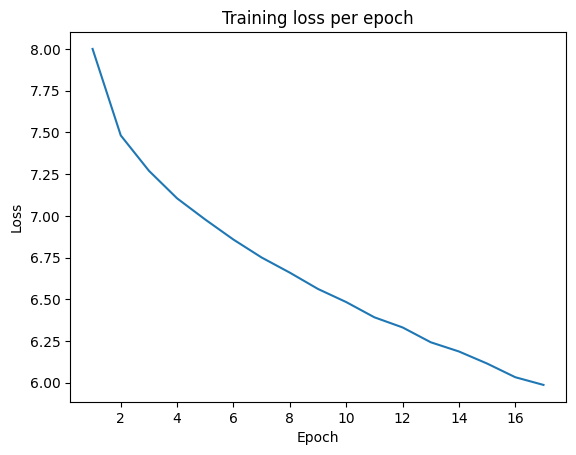

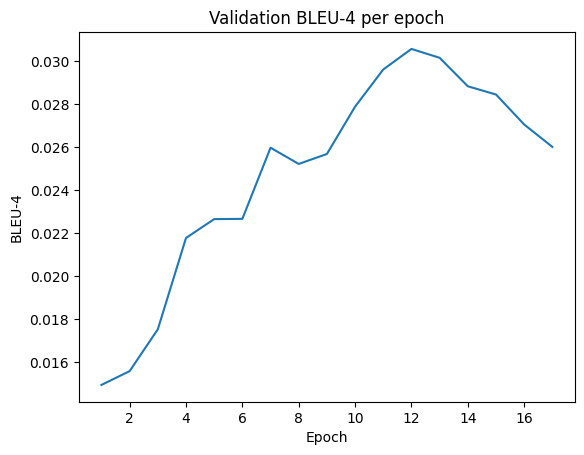

In [22]:
epochs_ran = range(1, len(history['train_loss']) + 1)

# Training loss
plt.plot(epochs_ran, history['train_loss'])
plt.title('Training loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig(os.path.join(DATA_PATH, 'training_loss.png'))
plt.show()

# Validation BLEU-4
plt.plot(epochs_ran, history['validation_bleu4'])
plt.title('Validation BLEU-4 per epoch')
plt.xlabel('Epoch')
plt.ylabel('BLEU-4')
plt.savefig(os.path.join(DATA_PATH, 'validation_bleu4.png'))
plt.show()

## Evaluation

In [23]:
# Load best checkpoint
checkpoint = torch.load(os.path.join(CHECKPOINT_PATH, 'best_model.pt'), map_location=device)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

def beam_search(enc_flat):
    k = BEAM_SIZE
    enc_flat = enc_flat.expand(k, *enc_flat.shape[1:])
    seqs = torch.full((k, 1), stoi['<START>'],dtype=torch.long, device=device)
    scores = torch.zeros(k, device=device)
    completed = []

    h, c = decoder.init_hidden_state(enc_flat)

    for x in range(MAX_CAPTION_LEN):
        emb = decoder.embedding(seqs[:, -1])
        context, _ = decoder.attention(enc_flat, h)
        gate = decoder.sigmoid(decoder.f_beta(h))
        context = gate * context
        h, c = decoder.decode_step(torch.cat([emb, context], dim=1), (h, c))

        logprobs = F.log_softmax(decoder.fc(h), dim=1)

        # Avoids unknowns in captions
        logprobs[:, stoi['<UNK>']] = -1e9

        top_scores, top_ids = (scores.unsqueeze(1) + logprobs).view(-1).topk(k)
        prev_beam = top_ids // vocab_size
        next_word = top_ids % vocab_size
        seqs = torch.cat([seqs[prev_beam], next_word.unsqueeze(1)], dim=1)
        scores = top_scores
        h, c = h[prev_beam], c[prev_beam]
        enc_flat = enc_flat[prev_beam]

        incomplete = []
        for i, w in enumerate(next_word):
            if w.item() == stoi['<END>']:
                completed.append((scores[i].item(), seqs[i, 1:-1].tolist()))
            else:
                incomplete.append(i)

        if not incomplete or len(completed) >= k:
            break

        keep = torch.tensor(incomplete, device=device)
        seqs = seqs[keep]
        scores = scores[keep]
        h = h[keep]
        c = c[keep]
        enc_flat = enc_flat[keep]
        k = len(keep)

    if completed:
        return max(completed, key=lambda x: x[0] / max(len(x[1]), 1))[1]
    return seqs[0, 1:].tolist()

# Generate captions for test images
encoder.eval()
decoder.eval()
ref_tokens = []
ref_strings = []
hyp_tokens = []
hyp_strings = []

with torch.no_grad():
    for images, captions, lengths in test_loader:
        images = images.to(device)
        encoder_out = encoder(images)

        for i in range(images.shape[0]):
            ref = [itos[index.item()] for index in captions[i] if index.item() not in (0, 1, 2)]
            ref_tokens.append([ref])

            enc_i = encoder_out[i].unsqueeze(0)
            enc_flat = enc_i.view(1, -1, ENCODER_DIM)
            gen = beam_search(enc_flat)
            hyp = [itos.get(index, '') for index in gen]

            hyp_tokens.append(hyp)
            ref_strings.append(' '.join(ref))
            hyp_strings.append(' '.join(hyp))

print(f' Example 1: Reference: {ref_strings[0]} \n Generated: {hyp_strings[0]}')
print(f' Example 2: Reference: {ref_strings[1]} \n Generated: {hyp_strings[1]}')

 Example 1: Reference: ct chest axial view showing a huge ascending aortic aneurysm ( * ) . 
 Generated: ct scan of the chest showing a large right lower lobe mass with a large mass in the right upper lobe .
 Example 2: Reference: computed tomography ( ct ) shows floating thrombosis ( white arrow ) 
 Generated: a large aortic valve ( arrow ) and the left ventricular outflow tract .


## Compute metrics

In [24]:
bleu1 = corpus_bleu(ref_tokens, hyp_tokens, weights=(1, 0, 0, 0), smoothing_function=SmoothingFunction().method1)
bleu4 = corpus_bleu(ref_tokens, hyp_tokens, weights=(.25, .25, .25, .25), smoothing_function=SmoothingFunction().method1)

meteor = sum(meteor_score(r, h) for r, h in zip(ref_tokens, hyp_tokens)) / len(ref_tokens)

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = sum(rouge.score(r, h)['rougeL'].fmeasure for r, h in zip(ref_strings, hyp_strings)) / len(ref_strings)

cider_refs = {str(i): [r] for i, r in enumerate(ref_strings)}
cider_hyps = {str(i): [h] for i, h in enumerate(hyp_strings)}
cider, _ = Cider().compute_score(cider_refs, cider_hyps)

P, R, F1 = bert_score_fn(hyp_strings, ref_strings, lang='en', verbose=False, device=str(device))
bert = F1.mean().item()

print('Test results:\n')
print(f'BLEU-1: {bleu1}')
print(f'BLEU-4: {bleu4}')
print(f'METEOR: {meteor}')
print(f'ROUGE-L: {rouge_l}')
print(f'CIDEr: {cider}')
print(f'BERTScore-F1: {bert}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test results:

BLEU-1: 0.17620695066253225
BLEU-4: 0.027758840994635436
METEOR: 0.17661515422079976
ROUGE-L: 0.2059214215467335
CIDEr: 0.16881480925239417
BERTScore-F1: 0.8579012155532837
